In [ ]:
import matplotlib.pyplot as plt
import osmnx as ox
ox.settings.use_cache = False
import pandas as pd
import geopandas as gpd
from sklearn.preprocessing import StandardScaler

In [59]:
import networkx as nx

Average longitude and latitude from Crime Data

In [ ]:
# Chicago
point = (41.823, -87.671)

Graph nodes from 2 km radius around point (use dist = 2000)

In [49]:
G = ox.graph_from_point(point, dist=1000, network_type='drive')

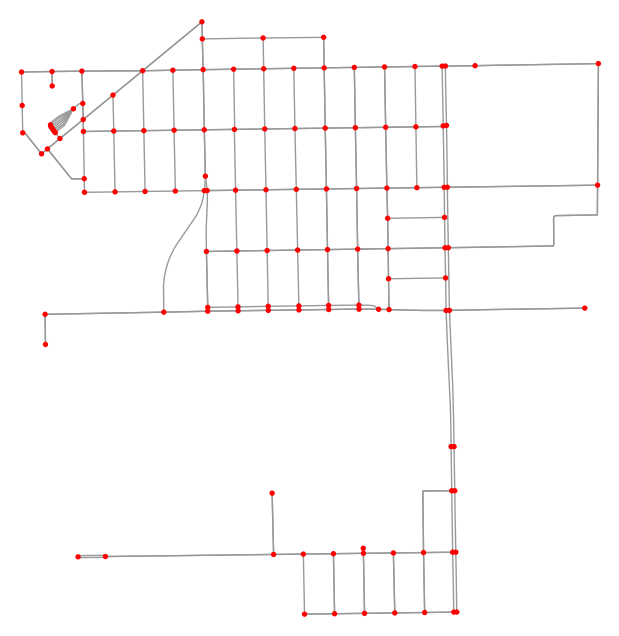

In [50]:
fig, ax = ox.plot_graph(G, node_color='r', edge_color='#999999', bgcolor='w')

In [51]:
nodes = ox.graph_to_gdfs(G, edges=False)
nodes

,y,x,street_count,highway,junction,geometry
osmid,,,,,,
261089187,41.823134,-87.673867,3,NaN,NaN,POINT (-87.67387 41.82313)
261099127,41.824919,-87.675146,3,NaN,NaN,POINT (-87.67515 41.82492)
261099134,41.823121,-87.675093,3,traffic_signals,NaN,POINT (-87.67509 41.82312)
261112971,41.827107,-87.680077,3,NaN,NaN,POINT (-87.68008 41.82711)
261125474,41.823183,-87.668987,3,NaN,NaN,POINT (-87.66899 41.82318)
...,...,...,...,...,...,...
7462153699,41.823179,-87.668196,3,NaN,NaN,POINT (-87.6682 41.82318)
11237475900,41.815734,-87.680327,2,NaN,NaN,POINT (-87.68033 41.81573)
11237475901,41.815743,-87.679223,2,NaN,NaN,POINT (-87.67922 41.81574)


Create dataframe of crime statistics

In [52]:
# Import csv of crimeData from github
df = pd.read_csv("/Users/meghaiyer/Downloads/crimeData.csv")
# Drop irrelevant columns
df = df.drop(columns=['uid', 'address', 'city_name', 'offense_code', 'offense_type', 'date_single', 'location_category', 'fips_state',
                      'fips_county', 'tract', 'block_group', 'block'])
df.head(5)

,longitude,latitude,location_type
0,-87.751482,41.894009,street
1,-87.710383,41.752417,residence
2,-87.607485,41.723546,street
3,-87.570235,41.751678,street
4,-87.570235,41.751678,street


Turn data frames into GeoDataFrames

In [53]:
gdf_crime = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326")

Link points of interest to nearest node on graph

In [54]:
# We use 'sjoin_nearest' because POIs might not be exactly on the node coordinates
nodes_with_pois = gpd.sjoin_nearest(nodes, gdf_crime, how="left", distance_col="dist")
nodes_with_pois.head(5)

/usr/local/lib/python3.9/site-packages/geopandas/array.py:403: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


,y,x,street_count,highway,junction,geometry,index_right,longitude,latitude,location_type,dist
osmid,,,,,,,,,,,
261089187,41.823134,-87.673867,3,NaN,NaN,POINT (-87.67387 41.82313),278,-87.669997,41.815043,street,0.008969
261099127,41.824919,-87.675146,3,NaN,NaN,POINT (-87.67515 41.82492),113,-87.678974,41.831182,other open space,0.007341
261099134,41.823121,-87.675093,3,traffic_signals,NaN,POINT (-87.67509 41.82312),113,-87.678974,41.831182,other open space,0.008946
261112971,41.827107,-87.680077,3,NaN,NaN,POINT (-87.68008 41.82711),113,-87.678974,41.831182,other open space,0.004222
261125474,41.823183,-87.668987,3,NaN,NaN,POINT (-87.66899 41.82318),278,-87.669997,41.815043,street,0.008202


Count points of interest by category for each node

In [55]:
poi_counts = nodes_with_pois.groupby([nodes_with_pois.index, 'location_type']).size().unstack(fill_value=0)
poi_counts

location_type,other open space,private vehicle,street
osmid,,,
261089187,0,0,1
261099127,1,0,0
261099134,1,0,0
261112971,1,0,0
261125474,0,0,1
...,...,...,...
7462153699,0,0,1
11237475900,0,0,1
11237475901,0,0,1


Aggregate

In [56]:
nodes_with_crime = gpd.sjoin_nearest(nodes, gdf_crime, how="left")
crime_counts = nodes_with_crime.groupby(nodes_with_crime.index).size()

/usr/local/lib/python3.9/site-packages/geopandas/array.py:403: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


Build final feature matrix X

In [57]:
# Merge the crime counts and POI categories
X_df = pd.merge(poi_counts, crime_counts.to_frame('crime_count'), left_index=True, right_index=True, how='right').fillna(0)
X_df.head(5)

,other open space,private vehicle,street,crime_count
osmid,,,,
261089187,0,0,1,1
261099127,1,0,0,1
261099134,1,0,0,1
261112971,1,0,0,1
261125474,0,0,1,1


In [ ]:
# StandardScaler() turns points into Z-scores
scaler = StandardScaler()
X_matrix = scaler.fit_transform(X_df)
# Numbers represent "hot spots" for crime
X_matrix

array([[-1.05765971, -0.15681251,  1.1100193 ,  0.        ],
       [ 0.94548368, -0.15681251, -0.90088523,  0.        ],
       [ 0.94548368, -0.15681251, -0.90088523,  0.        ],
       [ 0.94548368, -0.15681251, -0.90088523,  0.        ],
       [-1.05765971, -0.15681251,  1.1100193 ,  0.        ],
       [-1.05765971, -0.15681251,  1.1100193 ,  0.        ],
       [-1.05765971, -0.15681251,  1.1100193 ,  0.        ],
       [-1.05765971, -0.15681251,  1.1100193 ,  0.        ],
       [ 0.94548368, -0.15681251, -0.90088523,  0.        ],
       [ 0.94548368, -0.15681251, -0.90088523,  0.        ],
       [ 0.94548368, -0.15681251, -0.90088523,  0.        ],
       [-1.05765971, -0.15681251,  1.1100193 ,  0.        ],
       [-1.05765971, -0.15681251,  1.1100193 ,  0.        ],
       [-1.05765971, -0.15681251,  1.1100193 ,  0.        ],
       [-1.05765971, -0.15681251,  1.1100193 ,  0.        ],
       [-1.05765971, -0.15681251,  1.1100193 ,  0.        ],
       [-1.05765971, -0.

In [ ]:
# M x N matrix
# N different types of places
# N data points
X_matrix.shape

(125, 4)